<a href="https://colab.research.google.com/github/Nada-Elghaweet/Speaker_Diarization/blob/abdulla/f33_hubert_lightweight_transformer_FIXED_PATH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Speaker-Aware Transcription using Pretrained HuBERT + Lightweight Transformer + Whisper — Fixed Audio Search

Corrected pipeline:

```text
Audio Segment
    ├── HuBERT → Masked Mean Pooling → 768 Embedding → L2 Normalization → Lightweight Transformer Classifier → Speaker Label
    └── Whisper → Text Transcription

Final Output = Predicted Speaker Label + Whisper Text
```

This version includes a stronger recursive audio-file finder to avoid the `No .wav files found` error when AMI files are inside nested folders.

**Important:** if you only have very few non-silent segments, a 100% accuracy is not a real final accuracy. It is only training/demo accuracy and probably overfitting.


## 1. Install dependencies

In [5]:
!pip install -q transformers torchaudio librosa soundfile scikit-learn pandas tqdm matplotlib

## 2. Imports and setup

In [6]:
import os, glob, random, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio

from tqdm.auto import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA

from transformers import Wav2Vec2FeatureExtractor, HubertModel, pipeline

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


## 3. Mount Google Drive

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 4. Configuration
Change `DATA_ROOT` to the folder that contains AMI `.wav` headset files. The search is recursive.

In [8]:
DATA_ROOT = "/content/drive/MyDrive"   # safest default: search all MyDrive recursively
SELECTED_MEETINGS = []  # example: ["EN2001a", "EN2002a"] or [] for all wav files

TARGET_SR = 16000
WINDOW_SECONDS = 30
HOP_SECONDS = 25
MIN_SEGMENT_SECONDS = 3
RMS_SILENCE_THRESHOLD = 0.005
MAX_SEGMENTS_PER_SPEAKER = None  # set e.g. 20 for fast balanced demo

HUBERT_MODEL_NAME = "facebook/hubert-base-ls960"
WHISPER_MODEL_NAME = "openai/whisper-base"  # use openai/whisper-tiny if Colab is slow

EPOCHS = 25
BATCH_SIZE = 8
LR = 1e-4
WEIGHT_DECAY = 1e-2
DROPOUT = 0.4
D_MODEL = 128
NHEAD = 4
NUM_LAYERS = 1

OUTPUT_DIR = "/content/drive/MyDrive/AMI_outputs_hubert_traJnsformer"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("SELECTED_MEETINGS:", SELECTED_MEETINGS)
print("OUTPUT_DIR:", OUTPUT_DIR)


DATA_ROOT: /content/drive/MyDrive
SELECTED_MEETINGS: []
OUTPUT_DIR: /content/drive/MyDrive/AMI_outputs_hubert_traJnsformer


## 5. Find AMI audio files and infer speaker labels
For AMI headset channels, each headset file is treated as one speaker channel.

In [9]:
import os
import glob
import re


def find_audio_files(data_root, selected_meetings=None):
    """
    Find .wav files recursively inside DATA_ROOT.

    If selected_meetings is empty/None:
        return all .wav files under DATA_ROOT.

    If selected_meetings has meeting IDs:
        keep files whose full path or filename contains one of these IDs.

    This fixes the common problem where AMI files are nested like:
        /content/drive/MyDrive/AMI/EN2001a/audio/EN2001a.Headset-0.wav
    or:
        /content/drive/MyDrive/some_folder/.../EN2001a.Headset-0.wav
    """
    if not os.path.exists(data_root):
        raise FileNotFoundError(f"DATA_ROOT does not exist: {data_root}")

    all_wav_files = sorted(
        glob.glob(os.path.join(data_root, "**", "*.wav"), recursive=True)
    )

    if selected_meetings is None or len(selected_meetings) == 0:
        return all_wav_files

    selected_meetings = [str(m).lower().strip() for m in selected_meetings]

    filtered_files = []
    for path in all_wav_files:
        full_path_lower = path.lower()
        base_lower = os.path.basename(path).lower()

        for meeting in selected_meetings:
            if meeting in full_path_lower or meeting in base_lower:
                filtered_files.append(path)
                break

    return sorted(set(filtered_files))


def infer_speaker_from_filename(path):
    """
    Infer speaker label from AMI headset filename.

    Supported examples:
        ES2002a.Headset-0.wav -> SPEAKER_0
        ES2002a.Headset_1.wav -> SPEAKER_1
        ES2002a.Headset 2.wav -> SPEAKER_2
        speaker-3.wav          -> SPEAKER_3
    """
    base = os.path.basename(path)
    lower = base.lower()

    # Common AMI patterns: Headset-0, Headset_0, Headset 0, headset0
    m = re.search(r"headset[-_\s]?(\d+)", lower)
    if m:
        return f"SPEAKER_{m.group(1)}"

    # Fallback patterns: speaker0, speaker_0, speaker-0
    m = re.search(r"speaker[-_\s]?(\d+)", lower)
    if m:
        return f"SPEAKER_{m.group(1)}"

    # Final fallback: use file name without extension
    return os.path.splitext(base)[0]


audio_files = find_audio_files(DATA_ROOT, SELECTED_MEETINGS)

print("DATA_ROOT exists:", os.path.exists(DATA_ROOT))
print("DATA_ROOT:", DATA_ROOT)
print("SELECTED_MEETINGS:", SELECTED_MEETINGS)
print("Number of wav files found:", len(audio_files))

for f in audio_files[:30]:
    print("-", f, "=>", infer_speaker_from_filename(f))

if len(audio_files) == 0:
    print("\nNo .wav files found. Running quick extension diagnosis under MyDrive...")
    for ext in ["wav", "WAV", "flac", "mp3", "m4a", "sph"]:
        matches = glob.glob(f"/content/drive/MyDrive/**/*.{ext}", recursive=True)
        print(f".{ext}:", len(matches))
        for sample in matches[:3]:
            print("   ", sample)

    raise FileNotFoundError(
        "No .wav files found. Check DATA_ROOT, SELECTED_MEETINGS, Google Drive mount, "
        "or whether your audio files use another extension like .flac/.mp3/.sph."
    )


DATA_ROOT exists: True
DATA_ROOT: /content/drive/MyDrive
SELECTED_MEETINGS: []
Number of wav files found: 41
- /content/drive/MyDrive/AMI_Corpus/EN2001a/audio/EN2001a.Headset-0.wav => SPEAKER_0
- /content/drive/MyDrive/AMI_Corpus/EN2001a/audio/EN2001a.Headset-1.wav => SPEAKER_1
- /content/drive/MyDrive/AMI_Corpus/EN2001a/audio/EN2001a.Headset-2.wav => SPEAKER_2
- /content/drive/MyDrive/AMI_Corpus/EN2001a/audio/EN2001a.Headset-3.wav => SPEAKER_3
- /content/drive/MyDrive/AMI_Corpus/EN2001a/audio/EN2001a.Headset-4.wav => SPEAKER_4
- /content/drive/MyDrive/AMI_Corpus/EN2002a/audio/EN2002a.Headset-0.wav => SPEAKER_0
- /content/drive/MyDrive/AMI_Corpus/EN2002a/audio/EN2002a.Headset-1.wav => SPEAKER_1
- /content/drive/MyDrive/AMI_Corpus/EN2002a/audio/EN2002a.Headset-2.wav => SPEAKER_2
- /content/drive/MyDrive/AMI_Corpus/EN2002a/audio/EN2002a.Headset-3.wav => SPEAKER_3
- /content/drive/MyDrive/AMI_Corpus/EN2003a/audio/EN2003a.Headset-0.wav => SPEAKER_0
- /content/drive/MyDrive/AMI_Corpus/EN200

## 6. Load audio, split into windows, remove silence

In [10]:
def load_audio_mono(path, target_sr=16000):
    waveform, sr = torchaudio.load(path)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sr != target_sr:
        waveform = torchaudio.transforms.Resample(sr, target_sr)(waveform)
    return waveform.squeeze(0).numpy().astype(np.float32), target_sr


def create_windows(audio, sr, window_seconds=30, hop_seconds=25, min_segment_seconds=3):
    window_size = int(window_seconds * sr)
    hop_size = int(hop_seconds * sr)
    min_size = int(min_segment_seconds * sr)
    windows = []
    start = 0
    while start < len(audio):
        end = start + window_size
        segment = audio[start:end]
        if len(segment) < min_size:
            break
        windows.append({
            "start_sample": start,
            "end_sample": min(end, len(audio)),
            "start_time": start / sr,
            "end_time": min(end, len(audio)) / sr,
            "audio": segment,
        })
        start += hop_size
    return windows


def rms_energy(audio):
    return float(np.sqrt(np.mean(np.square(audio)) + 1e-12))


def is_non_silent(audio, threshold=0.005):
    return rms_energy(audio) >= threshold

## 7. Build segment dataset

In [11]:
segments = []
per_speaker_counts = Counter()

for audio_path in tqdm(audio_files, desc="Processing audio files"):
    speaker_label = infer_speaker_from_filename(audio_path)
    if MAX_SEGMENTS_PER_SPEAKER is not None and per_speaker_counts[speaker_label] >= MAX_SEGMENTS_PER_SPEAKER:
        continue

    audio, sr = load_audio_mono(audio_path, TARGET_SR)
    windows = create_windows(audio, sr, WINDOW_SECONDS, HOP_SECONDS, MIN_SEGMENT_SECONDS)

    for idx, win in enumerate(windows):
        if not is_non_silent(win["audio"], RMS_SILENCE_THRESHOLD):
            continue
        if MAX_SEGMENTS_PER_SPEAKER is not None and per_speaker_counts[speaker_label] >= MAX_SEGMENTS_PER_SPEAKER:
            break
        segments.append({
            "speaker": speaker_label,
            "source_file": os.path.basename(audio_path),
            "window_index": idx,
            "start_time": win["start_time"],
            "end_time": win["end_time"],
            "audio": win["audio"],
            "rms": rms_energy(win["audio"]),
        })
        per_speaker_counts[speaker_label] += 1

print("Total non-silent segments:", len(segments))
print("Segments per speaker:", Counter([s["speaker"] for s in segments]))

if len(segments) == 0:
    raise ValueError("No non-silent segments found. Lower RMS_SILENCE_THRESHOLD.")

pd.DataFrame([{k:v for k,v in s.items() if k != "audio"} for s in segments]).head()

Processing audio files:   0%|          | 0/41 [00:00<?, ?it/s]

Total non-silent segments: 2359
Segments per speaker: Counter({'SPEAKER_1': 710, 'SPEAKER_0': 518, 'SPEAKER_3': 502, 'SPEAKER_2': 458, 'SPEAKER_4': 171})


,speaker,source_file,window_index,start_time,end_time,rms
0,SPEAKER_0,EN2001a.Headset-0.wav,0,0.0,30.0,0.005695
1,SPEAKER_0,EN2001a.Headset-0.wav,1,25.0,55.0,0.005223
2,SPEAKER_0,EN2001a.Headset-0.wav,93,2325.0,2355.0,0.005678
3,SPEAKER_0,EN2001a.Headset-0.wav,107,2675.0,2705.0,0.005212
4,SPEAKER_1,EN2001a.Headset-1.wav,3,75.0,105.0,0.005854


## 8. Load pretrained HuBERT

In [12]:
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(HUBERT_MODEL_NAME)
hubert_model = HubertModel.from_pretrained(HUBERT_MODEL_NAME).to(DEVICE)
hubert_model.eval()
print("HuBERT loaded:", HUBERT_MODEL_NAME)

preprocessor_config.json:   0%|          | 0.00/213 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

HuBERT loaded: facebook/hubert-base-ls960


## 9. Extract HuBERT 768 embeddings with masked mean pooling + L2 normalization
This is the stronger extraction step:
- Attention mask prevents padding from affecting the embedding.
- Masked mean pooling averages only real audio frames.
- L2 normalization stabilizes embedding scale.

In [13]:
def masked_mean_pooling(last_hidden_state, attention_mask=None):
    # last_hidden_state: [batch, time, hidden]
    # attention_mask: [batch, input_samples]
    if attention_mask is None:
        return last_hidden_state.mean(dim=1)
    mask = attention_mask.float().unsqueeze(1)  # [batch, 1, samples]
    mask = F.interpolate(mask, size=last_hidden_state.shape[1], mode="nearest")
    mask = mask.squeeze(1).unsqueeze(-1)       # [batch, time, 1]
    summed = (last_hidden_state * mask).sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-6)
    return summed / counts


@torch.no_grad()
def extract_hubert_embedding(audio_segment, sr=16000):
    inputs = feature_extractor(
        audio_segment,
        sampling_rate=sr,
        return_tensors="pt",
        padding=True,
        return_attention_mask=True,
    )
    input_values = inputs.input_values.to(DEVICE)
    attention_mask = inputs.attention_mask.to(DEVICE) if "attention_mask" in inputs else None
    outputs = hubert_model(input_values, attention_mask=attention_mask)
    pooled = masked_mean_pooling(outputs.last_hidden_state, attention_mask)
    normalized = F.normalize(pooled, p=2, dim=1)
    return normalized.squeeze(0).cpu().numpy().astype(np.float32)

## 10. Extract embeddings for all segments

In [14]:
embeddings, labels = [], []
for seg in tqdm(segments, desc="Extracting HuBERT embeddings"):
    embeddings.append(extract_hubert_embedding(seg["audio"], TARGET_SR))
    labels.append(seg["speaker"])

X = np.stack(embeddings)
y_text = np.array(labels)

print("Input HuBERT embedding shape:", torch.tensor(X).shape)
print("Speaker distribution:", Counter(y_text))

Extracting HuBERT embeddings:   0%|          | 0/2359 [00:00<?, ?it/s]

Input HuBERT embedding shape: torch.Size([2359, 768])
Speaker distribution: Counter({np.str_('SPEAKER_1'): 710, np.str_('SPEAKER_0'): 518, np.str_('SPEAKER_3'): 502, np.str_('SPEAKER_2'): 458, np.str_('SPEAKER_4'): 171})


## 11. PCA visualization by true speaker

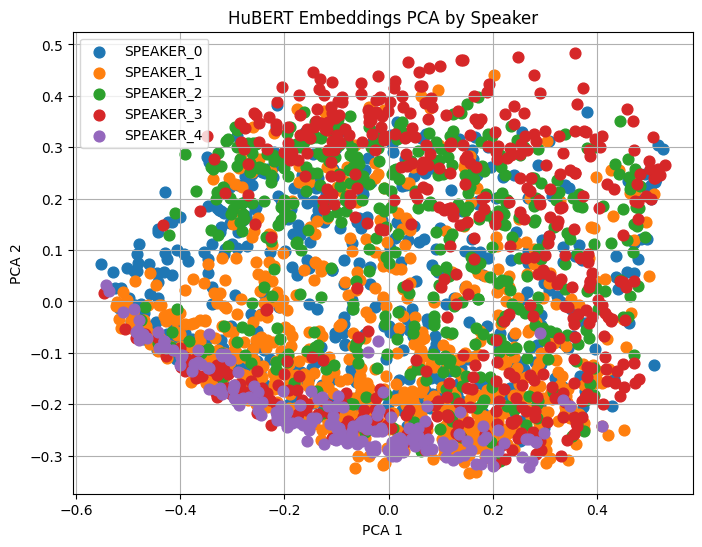

In [15]:
if len(X) >= 2:
    X_2d = PCA(n_components=2, random_state=SEED).fit_transform(X)
    plt.figure(figsize=(8, 6))
    for spk in sorted(set(y_text)):
        idx = y_text == spk
        plt.scatter(X_2d[idx, 0], X_2d[idx, 1], label=spk, s=60)
    plt.title("HuBERT Embeddings PCA by Speaker")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("Not enough samples for PCA.")

## 12. Label encoding and evaluation mode
If the dataset is too small or imbalanced, the notebook uses training/demo mode and prints a warning.

In [16]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)
num_classes = len(label_encoder.classes_)

print("Number of speaker classes:", num_classes)
print("Speaker classes:", list(label_encoder.classes_))

class_counts = Counter(y)
min_class_count = min(class_counts.values())
print("Encoded class counts:", class_counts)

can_split = (len(X) >= 20) and (min_class_count >= 2) and (num_classes >= 2)

if can_split:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=SEED, stratify=y
    )
    EVAL_MODE = "proper_train_test_split"
else:
    X_train, X_test, y_train, y_test = X, X, y, y
    EVAL_MODE = "training_demo_overfit_risk"

print("Evaluation mode:", EVAL_MODE)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

if EVAL_MODE == "training_demo_overfit_risk":
    print("WARNING: Small/imbalanced data. Accuracy below is training/demo accuracy, not final generalization accuracy.")

Number of speaker classes: 5
Speaker classes: [np.str_('SPEAKER_0'), np.str_('SPEAKER_1'), np.str_('SPEAKER_2'), np.str_('SPEAKER_3'), np.str_('SPEAKER_4')]
Encoded class counts: Counter({np.int64(1): 710, np.int64(0): 518, np.int64(3): 502, np.int64(2): 458, np.int64(4): 171})
Evaluation mode: proper_train_test_split
Train shape: (1769, 768)
Test shape: (590, 768)


## 13. Lightweight Transformer Speaker Classifier
This is the required part:

```text
HuBERT 768 embedding → Transformer Classifier → Speaker Label
```

To reduce overfitting, the classifier is intentionally small: one layer, dropout, AdamW, weight decay, and fewer epochs.

In [17]:
class SmallTransformerSpeakerClassifier(nn.Module):
    def __init__(self, input_dim=768, num_classes=3, d_model=128, nhead=4, num_layers=1, dropout=0.4):
        super().__init__()
        self.projection = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 2,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes)
        )

    def forward(self, x):
        # x: [batch, 768]
        x = self.projection(x)       # [batch, d_model]
        x = x.unsqueeze(1)           # [batch, seq_len=1, d_model]
        x = self.transformer(x)      # [batch, 1, d_model]
        x = x[:, 0, :]               # [batch, d_model]
        return self.classifier(x)


model = SmallTransformerSpeakerClassifier(
    input_dim=X.shape[1],
    num_classes=num_classes,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(DEVICE)

print(model)

SmallTransformerSpeakerClassifier(
  (projection): Linear(in_features=768, out_features=128, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.4, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.4, inplace=False)
        (dropout2): Dropout(p=0.4, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (1): Dropout(p=0.4, inplace=False)
    (2): Linear(in_features=128, out_features=5, bias=True)
  )

## 14. Train the Transformer classifier

In [18]:
from torch.utils.data import TensorDataset, DataLoader

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=min(BATCH_SIZE, len(X_train_t)),
    shuffle=True,
)

# Class weights help with imbalance
train_counts = Counter(y_train)
weights = [len(y_train) / (num_classes * max(train_counts.get(c, 1), 1)) for c in range(num_classes)]
class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

loss_history = []
for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(xb)
    avg_loss = total_loss / len(X_train_t)
    loss_history.append(avg_loss)
    if epoch == 1 or epoch % 5 == 0 or epoch == EPOCHS:
        print(f"Epoch {epoch:03d}/{EPOCHS} - loss: {avg_loss:.4f}")

Epoch 001/25 - loss: 1.5892
Epoch 005/25 - loss: 0.8098
Epoch 010/25 - loss: 0.5831
Epoch 015/25 - loss: 0.4942
Epoch 020/25 - loss: 0.4312
Epoch 025/25 - loss: 0.3950


## 15. Evaluate the classifier
If the notebook is in demo mode, do **not** report this as final model performance.

In [ ]:
model.eval()
with torch.no_grad():
    logits = model(X_test_t.to(DEVICE))
    preds = logits.argmax(dim=1).cpu().numpy()

acc = accuracy_score(y_test, preds)

if EVAL_MODE == "proper_train_test_split":
    print(f"HuBERT embeddings + Transformer speaker classifier TEST accuracy: {acc * 100:.2f}%")
else:
    print(f"HuBERT embeddings + Transformer speaker classifier TRAINING/DEMO accuracy: {acc * 100:.2f}%")
    print("NOTE: This is not final model performance because the dataset is too small/imbalanced.")

print("Classification report:")
print(classification_report(y_test, preds, target_names=label_encoder.classes_, zero_division=0))

cm = confusion_matrix(y_test, preds, labels=np.arange(num_classes))
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(np.arange(num_classes), label_encoder.classes_, rotation=45)
plt.yticks(np.arange(num_classes), label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(loss_history, marker="o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

## 16. Add predicted speaker labels to segments

In [ ]:
model.eval()
with torch.no_grad():
    all_logits = model(torch.tensor(X, dtype=torch.float32).to(DEVICE))
    all_preds = all_logits.argmax(dim=1).cpu().numpy()

pred_speakers = label_encoder.inverse_transform(all_preds)
for seg, pred in zip(segments, pred_speakers):
    seg["predicted_speaker"] = pred

summary_df = pd.DataFrame([{k:v for k,v in s.items() if k != "audio"} for s in segments])
summary_df.head(20)

## 17. Load Whisper for transcription
Whisper is used for speech-to-text. It does not take HuBERT embeddings. The Transformer that takes HuBERT embeddings is the speaker classifier above.

In [ ]:
from transformers import WhisperProcessor, WhisperForConditionalGeneration
import torch

WHISPER_MODEL_NAME = "openai/whisper-base"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

processor = WhisperProcessor.from_pretrained(WHISPER_MODEL_NAME)
whisper_model = WhisperForConditionalGeneration.from_pretrained(WHISPER_MODEL_NAME).to(DEVICE)
whisper_model.eval()

forced_decoder_ids = processor.get_decoder_prompt_ids(
    language="english",
    task="transcribe"
)

print("Whisper loaded without pipeline:", WHISPER_MODEL_NAME)
print("Device:", DEVICE)

## 18. Transcribe segments and build final speaker-aware transcript

In [ ]:
def transcribe_with_whisper(audio_array, sampling_rate=16000):
    audio_array = audio_array.astype(np.float32)

    inputs = processor(
        audio_array,
        sampling_rate=sampling_rate,
        return_tensors="pt"
    )

    input_features = inputs.input_features.to(DEVICE)

    with torch.no_grad():
        predicted_ids = whisper_model.generate(
            input_features,
            forced_decoder_ids=forced_decoder_ids,
            max_new_tokens=128
        )

    text = processor.batch_decode(
        predicted_ids,
        skip_special_tokens=True
    )[0]

    return text.strip()

In [23]:
import numpy as np
import pandas as pd
from tqdm import tqdm

for seg in segments:
    if "predicted_speaker" not in seg:
        seg["predicted_speaker"] = seg.get("speaker", "UNKNOWN")

MAX_ASR_SEGMENTS = 30
segments_for_asr = segments[:MAX_ASR_SEGMENTS]

print("Total segments:", len(segments))
print("Whisper segments:", len(segments_for_asr))

results = []

for seg in tqdm(segments_for_asr, desc="Whisper transcription"):
    text = transcribe_with_whisper(
        seg["audio"],
        sampling_rate=TARGET_SR
    )

    results.append({
        "predicted_speaker": seg.get("predicted_speaker", "UNKNOWN"),
        "true_headset_speaker": seg.get("speaker", "UNKNOWN"),
        "source_file": seg.get("source_file", ""),
        "window_index": seg.get("window_index", -1),
        "start_time": round(seg.get("start_time", 0), 2),
        "end_time": round(seg.get("end_time", 0), 2),
        "text": text,
    })

df_results = pd.DataFrame(results)
df_results = df_results[df_results["text"].str.len() > 0].copy()
df_results = df_results.sort_values(
    ["start_time", "predicted_speaker"]
).reset_index(drop=True)

df_results.head(20)

Total segments: 2359
Whisper segments: 30


Whisper transcription:   0%|          | 0/30 [00:00<?, ?it/s]Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take 

,predicted_speaker,true_headset_speaker,source_file,window_index,start_time,end_time,text
0,SPEAKER_0,SPEAKER_0,EN2001a.Headset-0.wav,0,0.0,30.0,Does anyone want to see Steve's feedback from ...
1,SPEAKER_2,SPEAKER_0,EN2001a.Headset-0.wav,1,25.0,55.0,like duplication of effort and stuff and seein...
2,SPEAKER_1,SPEAKER_1,EN2001a.Headset-1.wav,3,75.0,105.0,"I mean, if we just want to have some data for ..."
3,SPEAKER_1,SPEAKER_1,EN2001a.Headset-1.wav,20,500.0,530.0,I thought we would just have like one big summ...
4,SPEAKER_1,SPEAKER_1,EN2001a.Headset-1.wav,21,525.0,555.0,zoom level as we just display a part of it. I ...
5,SPEAKER_1,SPEAKER_1,EN2001a.Headset-1.wav,25,625.0,655.0,But I think the difference might be that we wo...
6,SPEAKER_1,SPEAKER_1,EN2001a.Headset-1.wav,26,650.0,680.0,to be loading everything was that you load all...
7,SPEAKER_1,SPEAKER_1,EN2001a.Headset-1.wav,28,700.0,730.0,I'm getting quite lost at the moment because w...
8,SPEAKER_1,SPEAKER_1,EN2001a.Headset-1.wav,29,725.0,755.0,"the importance measure and the skimming, I mea..."
9,SPEAKER_1,SPEAKER_1,EN2001a.Headset-1.wav,34,850.0,880.0,"And yeah, I think we also thought about combin..."


## 19. Save outputs

In [24]:
transcript_lines = []

for _, row in df_results.iterrows():
    line = f"[{row['start_time']}s - {row['end_time']}s] {row['predicted_speaker']}: {row['text']}"
    transcript_lines.append(line)

final_transcript = "\n".join(transcript_lines)

csv_path = os.path.join(OUTPUT_DIR, "speaker_aware_transcription_hubert_transformer.csv")
txt_path = os.path.join(OUTPUT_DIR, "speaker_aware_transcription_hubert_transformer.txt")
model_path = os.path.join(OUTPUT_DIR, "hubert_transformer_speaker_classifier.pt")

df_results.to_csv(csv_path, index=False)

with open(txt_path, "w", encoding="utf-8") as f:
    f.write(final_transcript)

torch.save({
    "model_state_dict": model.state_dict(),
    "label_classes": list(label_encoder.classes_),
    "config": {
        "input_dim": int(X.shape[1]),
        "num_classes": int(num_classes),
        "d_model": D_MODEL,
        "nhead": NHEAD,
        "num_layers": NUM_LAYERS,
        "dropout": DROPOUT,
        "hubert_model": HUBERT_MODEL_NAME,
        "whisper_model": WHISPER_MODEL_NAME,
        "eval_mode": EVAL_MODE,
    }
}, model_path)

print("Final transcript preview:")
print(final_transcript[:3000])

print("\nSaved CSV to:", csv_path)
print("Saved TXT to:", txt_path)
print("Saved model to:", model_path)

Final transcript preview:
[0.0s - 30.0s] SPEAKER_0: Does anyone want to see Steve's feedback from the specification? Not really, just what he's talking about, duplication of effort and duplication of effort and stuff.
[25.0s - 55.0s] SPEAKER_2: like duplication of effort and stuff and seeing that we should maybe think about having a prototype for a week's sex which is next week so probably prioritise our packages
[75.0s - 105.0s] SPEAKER_1: I mean, if we just want to have some data for the user face could even be random data.
[500.0s - 530.0s] SPEAKER_1: I thought we would just have like one big summary, with only different importance levels. Displayed on it and depending on what our zoom level is, we just display a part of it.
[525.0s - 555.0s] SPEAKER_1: zoom level as we just display a part of it. I mean we would have one very big thing offline and from that we would just select what we are displaying. Yes, so for example you would give a high value to those sequences you want to dis

## Final explanation for your discussion

> In this pipeline, audio is divided into overlapping 30-second segments. Silent segments are removed. Each non-silent segment is passed into pretrained HuBERT to extract a 768-dimensional embedding. We use attention-mask mean pooling to avoid padding effects and L2 normalization to stabilize the embedding scale. The normalized embedding is then passed into a lightweight Transformer Encoder classifier to predict the speaker label. Whisper is used separately as a pretrained Transformer ASR model to transcribe the same audio segment. The final output combines the Transformer-predicted speaker label with the Whisper transcription.

**Important:** if the dataset is tiny, report the result as training/demo accuracy, not final test accuracy.